<a href="https://colab.research.google.com/github/maggiecrowner/DS5001-Final-Project/blob/main/Models2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Models

In [1]:
! git clone https://github.com/maggiecrowner/DS5001-Final-Project.git

Cloning into 'DS5001-Final-Project'...
remote: Enumerating objects: 173, done.
remote: Counting objects: 100% (173/173), done.
remote: Compressing objects: 100% (164/164), done.
remote: Total 173 (delta 50), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (173/173), 12.61 MiB | 4.77 MiB/s, done.
Resolving deltas: 100% (50/50), done.


In [31]:
!wget -O CORPUS.csv "https://virginia.box.com/shared/static/ijkqovrdgvrmctsdqobymig2p98q9x0m.csv"
!wget -O LIB.csv "https://virginia.box.com/shared/static/fhzudg34je9xls5bfcbi4xdnaiek74rj.csv"

--2026-04-15 00:49:28--  https://virginia.box.com/shared/static/ijkqovrdgvrmctsdqobymig2p98q9x0m.csv
Resolving virginia.box.com (virginia.box.com)... 74.112.186.157, 2620:117:bff0:12d::
Connecting to virginia.box.com (virginia.box.com)|74.112.186.157|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: /public/static/ijkqovrdgvrmctsdqobymig2p98q9x0m.csv [following]
--2026-04-15 00:49:28--  https://virginia.box.com/public/static/ijkqovrdgvrmctsdqobymig2p98q9x0m.csv
Reusing existing connection to virginia.box.com:443.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://virginia.app.box.com/public/static/ijkqovrdgvrmctsdqobymig2p98q9x0m.csv [following]
--2026-04-15 00:49:28--  https://virginia.app.box.com/public/static/ijkqovrdgvrmctsdqobymig2p98q9x0m.csv
Resolving virginia.app.box.com (virginia.app.box.com)... 74.112.186.157, 2620:117:bff0:12d::
Connecting to virginia.app.box.com (virginia.app.box.com)|74.112.186.157|:443.

In [34]:
import pandas as pd
CORPUS = pd.read_csv('CORPUS.csv', delimiter='|', index_col=[0,1,2,3])
LIB = pd.read_csv('LIB.csv', delimiter='|', index_col=0)

## LDA

In [17]:
DOCS = CORPUS[CORPUS.pos.str.match(r'^NNS?$')]\
    .groupby(['Artist', 'Album', 'Title']).term_str\
    .apply(lambda x: ' '.join(map(str,x)))\
    .to_frame()\
    .rename(columns={'term_str':'doc_str'})

In [18]:
from sklearn.feature_extraction import text
my_stop_words = list(text.ENGLISH_STOP_WORDS)

In [20]:
from sklearn.feature_extraction.text import CountVectorizer
count_engine = CountVectorizer(max_df=.9, min_df=10, stop_words=my_stop_words)
count_model = count_engine.fit_transform(DOCS.doc_str)
TERMS = count_engine.get_feature_names_out()
VOCAB = pd.DataFrame(index=TERMS)
VOCAB.index.name = 'term_str'
COUNTS = pd.DataFrame(count_model.toarray(), index=DOCS.index, columns=TERMS)
COUNTS

act  ...  yup
Artist        Album                                 Title                           ...     
Ariana Grande 13 (Original Broadway Cast Recording) Brand New You                0  ...    0
              Ariana Grande                         Ariana Grande Tour Guide     0  ...    0
                                                    I’m Every Woman/Vogue        0  ...    0
                                                    Leave Me Lonely (Reprise)    0  ...    0
                                                    Love Me Harder/breathin      0  ...    0
...                                                                            ...  ...  ...
Taylor Swift  “Taylor’s Songs” 2003 Demo            Lucky You                    0  ...    0
                                                    My Turn To Be Me             0  ...    0
                                                    Never Fade                   0  ...    0
                                                    Point of View                0  ...    0
                                                    Smokey Black Nights          0  ...    0

[2207 rows x 1181 columns]

In [21]:
COUNTS.to_csv("/content/DS5001-Final-Project/COUNTS.csv", sep="|", index=True)

In [22]:
import numpy as np
from sklearn.decomposition import LatentDirichletAllocation as LDA

n_topics = 20
max_iter = 100
n_top_terms = 9
TNAMES = [f"T{str(x).zfill(len(str(n_topics)))}" for x in range(n_topics)]
topic_engine = LDA(n_components=20, random_state=42)
topic_model = topic_engine.fit_transform(count_model)

### THETA

In [23]:
THETA = pd.DataFrame(topic_model, index=DOCS.index, columns=TNAMES)
THETA.columns.name = 'topic_id'
THETA.head()

topic_id                                                                            T00  ...       T19
Artist        Album                                 Title                                ...          
Ariana Grande 13 (Original Broadway Cast Recording) Brand New You              0.001250  ...  0.099840
              Ariana Grande                         Ariana Grande Tour Guide   0.002778  ...  0.002778
                                                    I’m Every Woman/Vogue      0.038265  ...  0.000704
                                                    Leave Me Lonely (Reprise)  0.002500  ...  0.066801
                                                    Love Me Harder/breathin    0.000685  ...  0.102071

[5 rows x 20 columns]

In [28]:
THETA.to_csv("/content/DS5001-Final-Project/THETA.csv", sep="|", index=True)

### PHI

In [24]:
PHI = pd.DataFrame(topic_engine.components_, columns=TERMS, index=TNAMES)
PHI.index.name = 'topic_id'
PHI.columns.name = 'term_str'
PHI.head()

term_str,act,adam,advice,affection,afraid,afternoon,age,ah,ahah,ahh,aim,aint,air,album,alright,america,amor,angel,angels,answer,answers,anybody,applause,ariana,arm,arms,art,ask,ass,attention,attitude,awake,ay,ayy,babe,babies,baby,babys,background,backseat,...,winter,wish,woah,woman,women,wonder,wont,woo,wood,word,words,work,world,worlds,worries,worry,worth,wouldnt,wow,wrap,wrist,ya,yah,yall,yeah,yeahyeah,year,years,yee,yes,yesterday,yo,york,youd,youll,youre,youth,youve,yuh,yup
topic_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
T00,0.050000,0.050000,0.050000,0.05,0.05,0.050000,0.050000,26.920135,0.05,0.05,0.050000,13.001994,0.079412,0.050000,3.178082,0.05,0.05,0.050000,0.05,0.050000,0.05,0.050000,0.05,0.05,0.05,11.551114,0.050000,16.191313,7.112129,11.593496,16.264747,2.033208,0.050000,0.050000,0.050000,0.05000,0.050002,0.05,7.220617,0.05,...,0.050000,0.05000,0.050000,0.050000,0.050000,0.050000,13.227771,31.593730,1.525783,0.050000,0.050000,23.045385,4.323854,0.050000,0.050000,0.050000,0.050000,1.05,0.050000,4.765068,0.05,0.050000,0.05,8.271703,4.312609,0.050000,0.050000,20.164824,6.765410,3.538150,0.050000,4.043830,10.575036,26.496026,42.270188,0.050000,0.05,9.728658,6.407605,0.050000
T01,7.607295,0.050000,0.050000,0.05,0.05,0.050000,0.050000,0.547858,0.05,0.05,0.050000,4.603005,51.850783,0.050000,3.705165,0.05,0.05,0.050000,0.05,0.050000,0.05,0.050000,0.05,0.05,0.05,1.374930,7.020179,0.050000,4.612382,0.050000,0.050000,3.760546,0.050000,0.050000,0.050000,0.05000,1.569630,0.05,0.050000,0.05,...,0.050000,0.05000,0.050000,1.745209,0.050000,0.050000,4.738684,0.636931,0.050000,0.050000,0.050000,3.974731,5.397276,0.050000,0.050000,0.050000,0.050000,0.05,0.050000,0.050000,0.05,2.364037,0.05,0.050000,18.516882,0.050000,1.838217,0.050000,1.426517,12.427035,0.050000,0.387412,0.729060,0.050000,0.050000,0.050000,0.05,0.050000,0.050000,0.050000
T02,8.455275,0.050000,8.576520,0.05,0.05,0.050000,2.360304,8.912592,0.05,0.05,5.826227,11.870828,0.539027,1.874438,0.050000,0.05,0.05,1.014675,0.05,1.006079,0.05,0.050000,0.05,0.05,0.05,3.076764,0.050000,0.050000,9.078899,2.151910,0.050000,0.050000,0.050000,0.050001,76.265880,3.56029,1.439728,0.05,0.050000,0.05,...,4.010125,6.54394,4.465405,47.855178,11.400716,3.616278,0.050000,0.050000,0.050000,21.482186,15.852413,3.292872,1.319275,7.368414,0.052631,0.050000,0.050000,0.05,3.048453,0.050000,0.05,3.050282,0.05,0.050000,13.482239,0.050000,11.386251,23.429367,6.206672,20.003816,10.875341,6.417447,0.050000,3.630781,24.037208,36.220418,0.05,12.429305,1.108078,16.579982
T03,0.050000,27.411892,0.050000,0.05,0.05,0.050000,0.050000,0.050000,0.05,0.05,0.050000,25.719076,2.061001,0.050000,0.050000,0.05,0.05,0.050000,0.05,0.050000,0.05,0.112889,0.05,0.05,0.05,0.065396,0.050000,0.050000,0.050000,2.791905,0.050000,0.050000,0.050000,0.050000,0.050000,0.05000,2.818074,1.05,0.050000,0.05,...,0.050000,0.05000,0.050000,0.050000,3.050000,0.050000,53.294545,5.801762,0.050000,16.096737,2.471144,3.881296,6.961457,0.050000,8.563741,7.456822,0.050000,0.05,0.050000,0.050000,0.05,0.050000,0.05,4.342087,6.722205,6.895919,0.050000,0.050000,0.050000,3.700951,0.050000,0.050000,0.050000,0.050000,6.118775,214.122178,0.05,2.359839,0.050000,0.050000
T04,0.050000,0.050000,0.408442,0.05,1.05,1.232819,0.050000,0.050000,0.05,0.05,0.050000,4.171831,0.050000,0.050000,0.050000,0.05,0.05,0.050000,0.05,0.050000,0.05,0.050000,0.05,0.05,0.05,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,1.261484,0.050000,10.603142,0.05000,2409.841273,0.05,0.050000,0.05,...,0.050000,0.05000,3.390441,0.050000,0.050000,0.050000,5.285609,0.050000,0.050000,8.623385,39.491490,18.929201,0.050000,0.050000,0.050000,0.050000,2.536362,0.05,0.050000,1.423595,0.05,0.050000,0.05,0.050000,262.289529,0.050000,0.050000,0.050000,0.050000,6.463854,0.050000,0.050000,9.984235,23.002324,0.068388,37.010386,0.05,0.050000,0.050000,3.228586


In [29]:
PHI.to_csv("/content/DS5001-Final-Project/PHI.csv", sep="|", index=True)

### TOPICS

In [26]:
n_top_terms = 5
TOPICS = PHI.stack().groupby('topic_id')\
    .apply(lambda x: ' '.join(x.sort_values(ascending=False).head(n_top_terms).reset_index().term_str))\
    .to_frame('top_terms')
TOPICS['mean_doc_weight'] = THETA.mean()
TOPICS = TOPICS.sort_values('mean_doc_weight', ascending=False)

In [27]:
TOPICS

,top_terms,mean_doc_weight
topic_id,,
T18,way im eyes night life,0.078764
T02,man time boy im day,0.072614
T07,home somebody lights youre look,0.067457
T13,girl heart time youre cause,0.066722
T06,yeah ah oh woah ill,0.064093
T14,time beyoncé face thing words,0.063991
T10,youre talk sun night dont,0.058800
T19,hey im grande dont ya,0.055376
T04,baby im yeah gonna dont,0.051726


In [30]:
labels = {
    'T18': 'Introspection',
    'T02': 'Daily Life',
    'T07': 'Longing',
    'T13': 'Romance',
    'T06': 'Ad-libs',
    'T14': 'Beyonce',
    'T10': 'Night',
    'T19': 'Ariana Grande',
    'T04': 'Pop',
    'T08': 'R&B',
    'T09': 'Uplifting',
    'T12': 'Holiday',
    'T15': 'Drama',
    'T11': 'Rap',
    'T00': 'Feminine',
    'T17': 'Justin Bieber',
    'T05': 'Vague',
    'T03': 'Confidence',
    'T01': 'Dance',
    'T16': 'Lady Gaga'
}

TOPICS['best_guess_label'] = TOPICS.index.map(labels)
TOPICS.to_csv("/content/DS5001-Final-Project/TOPICS.csv", sep="|", index=True)

##LDA and PCA Visualization

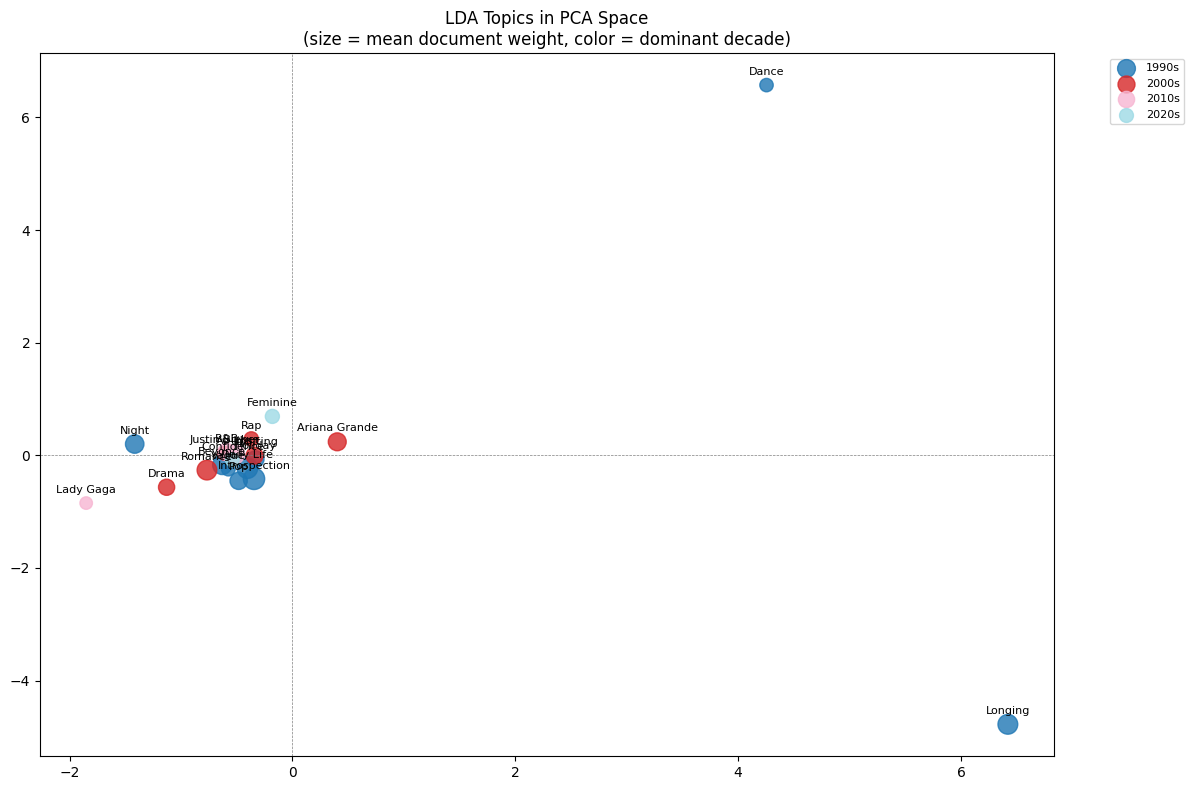

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

THETA_reset = THETA.reset_index()
THETA_reset['track_id'] = (
    THETA_reset['Artist'] + ' — ' +
    THETA_reset['Title'] + ' (' +
    THETA_reset['Album'] + ')'
)
THETA_reset = THETA_reset.join(LIB[['Decade']], on='track_id')

pca = PCA(n_components=5)
pca_coords = pca.fit_transform(THETA.T)

plot_df = TOPICS[['best_guess_label', 'mean_doc_weight']].copy()
plot_df['PC0'] = pca_coords[:, 0]
plot_df['PC1'] = pca_coords[:, 1]

topic_decade = []
for topic in THETA.columns:
    dominant = THETA_reset.groupby('Decade')[topic].mean().idxmax()
    topic_decade.append(dominant)

plot_df['Decade'] = topic_decade

decades = plot_df['Decade'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(decades)))
color_map = dict(zip(decades, colors))

fig, ax = plt.subplots(figsize=(12, 8))

for decade in decades:
    subset = plot_df[plot_df['Decade'] == decade]
    ax.scatter(
        subset['PC0'], subset['PC1'],
        s=subset['mean_doc_weight'] * 3000,
        color=color_map[decade],
        label=decade,
        alpha=0.8
    )
    for _, row in subset.iterrows():
        ax.annotate(
            row['best_guess_label'],
            (row['PC0'], row['PC1']),
            fontsize=8,
            ha='center',
            va='bottom',
            xytext=(0, 6),
            textcoords='offset points'
        )

ax.set_title("LDA Topics in PCA Space\n(size = mean document weight, color = dominant decade)")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.savefig("/content/DS5001-Final-Project/images/lda_pca_plot.png", dpi=150, bbox_inches='tight')
plt.show()